## Imports:

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Load the preprocessed data
processed_data = joblib.load('../models/processed_data.pkl')
label_encoder = joblib.load('../models/label_encoder.pkl')

X_train = processed_data['X_train']
X_test = processed_data['X_test'] 
y_train = processed_data['y_train']
y_test = processed_data['y_test']
category_names = processed_data['category_names']

print("Dataset Description: ")
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Categories: {category_names}")

Dataset Description: 
Training data shape: (6400, 60, 80, 3)
Test data shape: (1600, 60, 80, 3)
Categories: ['Dresses' 'Jackets' 'Pants' 'Shirts' 'Shoes' 'Sweaters' 'Tops' 'Tshirts']


## Model Creation and Compilation:

In [2]:
def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        # First Convolutional Block
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        
        # Second Convolutional Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        
        # Third Convolutional Block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        
        # Classifier
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Create model
input_shape = X_train.shape[1:]  # (60, 80, 3)
num_classes = len(category_names)

model = create_cnn_model(input_shape, num_classes)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Successfull")
model.summary()

C:\Users\DELL\anaconda3\envs\idsproj\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Successfull


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 60, 80, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 60, 80, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 60, 80, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 60, 80, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 30, 40, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 40, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 30, 40, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 30, 40, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 30, 40, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 30, 40, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 15, 20, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 15, 20, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 15, 20, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 15, 20, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 15, 20, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 15, 20, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 10, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 7, 10, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,618,280 (9.99 MB)

 Trainable params: 2,616,616 (9.98 MB)

 Non-trainable params: 1,664 (6.50 KB)

In [3]:
# Callbacks for better training
early_stopping = EarlyStopping( monitor='val_loss',patience=10,restore_best_weights=True,verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.2,patience=5,min_lr=0.00001,verbose=1)

# Parameters
batch_size = 32
epochs = 50

print(f"Batch size: {batch_size}")
print(f"Max epochs: {epochs}")

Batch size: 32
Max epochs: 50


## Training

In [4]:
# Train the model
history = model.fit(X_train, y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Get final accuracy
train_accuracy = history.history['accuracy'][-1]
val_accuracy = history.history['val_accuracy'][-1]

print(f"Final Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Final Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 140s 632ms/step - accuracy: 0.6977 - loss: 0.9358 - val_accuracy: 0.5113 - val_loss: 1.2615 - learning_rate: 0.0010
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 120s 597ms/step - accuracy: 0.7948 - loss: 0.5950 - val_accuracy: 0.6587 - val_loss: 0.8373 - learning_rate: 0.0010
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 115s 574ms/step - accuracy: 0.8353 - loss: 0.4752 - val_accuracy: 0.8462 - val_loss: 0.4254 - learning_rate: 0.0010
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 105s 524ms/step - accuracy: 0.8553 - loss: 0.4128 - val_accuracy: 0.7887 - val_loss: 0.6353 - learning_rate: 0.0010
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 92s 462ms/step - accuracy: 0.8709 - loss: 0.3739 - val_accuracy: 0.8512 - val_loss: 0.4139 - learning_rate: 0.0010
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 96s 480ms/step - accuracy: 0.8756 - loss: 0.3498 - val_accuracy: 0.8462 - val_loss: 0.4412 - learning_rate: 0.0010
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 96s 481ms/step - accuracy:

## Plotting Training: 

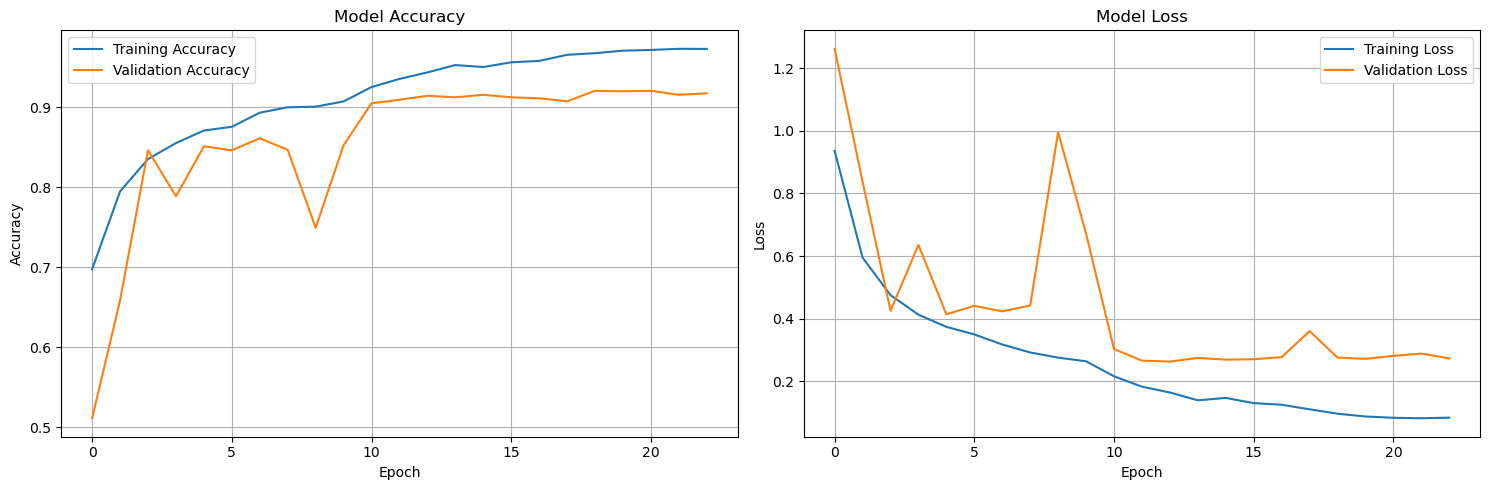

In [5]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print best accuracy
best_val_accuracy = max(history.history['val_accuracy'])
best_epoch = history.history['val_accuracy'].index(best_val_accuracy) + 1

## Evaluation

Test Accuracy: 0.9144 (91.44%)

Classification Report:
              precision    recall  f1-score   support

     Dresses       0.88      0.95      0.92       160
     Jackets       0.67      0.33      0.44        18
       Pants       1.00      0.98      0.99       128
      Shirts       0.85      0.94      0.89       208
       Shoes       0.99      1.00      0.99       470
    Sweaters       0.71      0.47      0.57        36
        Tops       0.73      0.70      0.72       132
     Tshirts       0.92      0.90      0.91       448

    accuracy                           0.91      1600
   macro avg       0.84      0.79      0.80      1600
weighted avg       0.91      0.91      0.91      1600



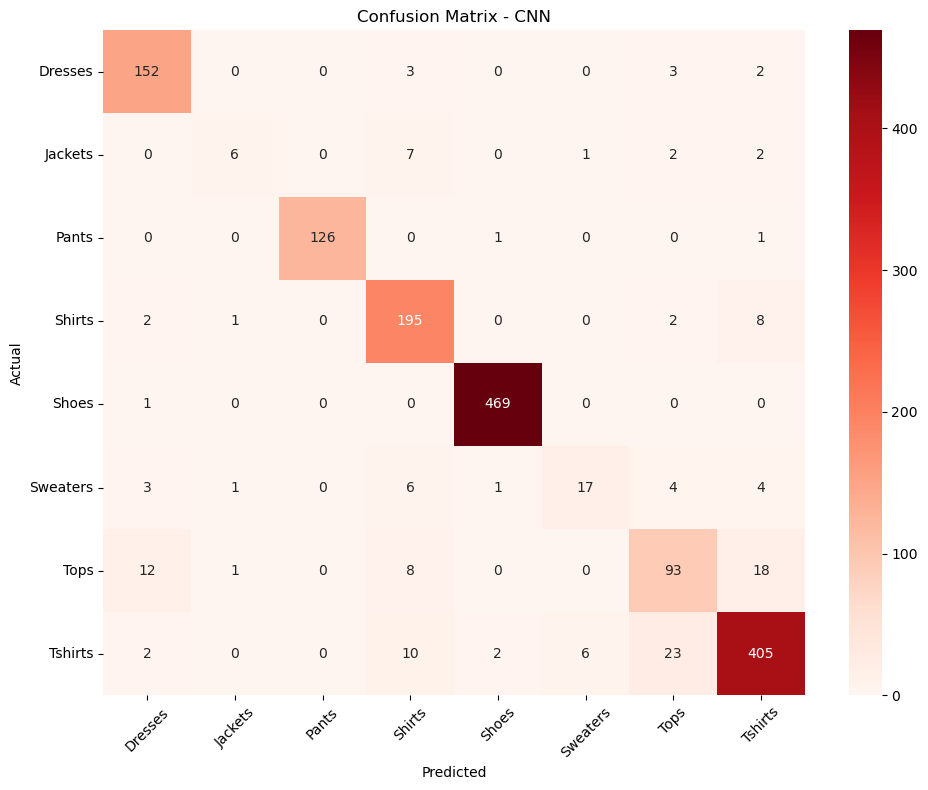

In [6]:
# Predict on test data
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# Calculate accuracy
test_accuracy = np.sum(y_pred == y_test) / len(y_test)

print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=category_names))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',xticklabels=category_names, yticklabels=category_names)
plt.title('Confusion Matrix - CNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Saving Model:

In [8]:
# Save the entire model in the recommended Keras format
model.save('../models/cnn_model.keras')

# Save model weights with correct extension
model.save_weights('../models/cnn_model.weights.h5')

# Save training history as pkl
history_data = {'history': history.history,'test_accuracy': test_accuracy,'best_accuracy': best_val_accuracy}

joblib.dump(history_data, '../models/cnn_training_history.pkl')

# Also save a simplified version for easy loading
model_info = {'input_shape': input_shape,'num_classes': num_classes,'category_names': category_names,'test_accuracy': test_accuracy}

joblib.dump(model_info, '../models/cnn_model_info.pkl')

['../models/cnn_model_info.pkl']

## Prediction: 

In [9]:
def predict_fashion_image_cnn_simple(image_array, cnn_model, label_encoder):
    # Ensure image is properly shaped and normalized
    if image_array.max() > 1.0:
        image_array = image_array / 255.0
    image_array = image_array.reshape(1, 60, 80, 3)
    
    # Predict
    probabilities = cnn_model.predict(image_array, verbose=0)[0]
    predicted_class_idx = np.argmax(probabilities)
    predicted_class = label_encoder.inverse_transform([predicted_class_idx])[0]
    confidence = probabilities[predicted_class_idx]
    
    # Get all probabilities
    all_probabilities = {label_encoder.inverse_transform([i])[0]: float(prob) for i, prob in enumerate(probabilities)}
    return predicted_class, confidence, all_probabilities

test_pred_class, test_confidence, test_all_probs = predict_fashion_image_cnn_simple(X_test[0], model, label_encoder)

## Final Results:

In [10]:
print(f"Final Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f} ({best_val_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

print(f"\nPerformance Summary:")
print(f"   - Number of epochs trained: {len(history.history['accuracy'])}")
print(f"   - Best epoch: {best_epoch}")

print(f"\nModel Architecture:")
print(f"   - Input shape: {input_shape}")
print(f"   - Number of parameters: {model.count_params():,}")
print(f"   - Number of layers: {len(model.layers)}")

print(f"\nComparison with Random Forest:")
rf_model_data = joblib.load('../models/random_forest_model.pkl')
rf_accuracy = rf_model_data['test_accuracy']
print(f"   - Random Forest Test Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"   - CNN Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   - Difference: {abs(test_accuracy - rf_accuracy):.4f}")

Final Training Accuracy: 0.9730 (97.30%)
Best Validation Accuracy: 0.9206 (92.06%)
Test Accuracy: 0.9144 (91.44%)

Performance Summary:
   - Number of epochs trained: 23
   - Best epoch: 19

Model Architecture:
   - Input shape: (60, 80, 3)
   - Number of parameters: 2,618,280
   - Number of layers: 26

Comparison with Random Forest:
   - Random Forest Test Accuracy: 0.8756 (87.56%)
   - CNN Test Accuracy: 0.9144 (91.44%)
   - Difference: 0.0388
